In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Load the dataset
df = pd.read_csv('Amazon Sale Report.csv')

print("✅ Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

✅ Dataset loaded successfully!
Dataset shape: (128975, 24)
Rows: 128975, Columns: 24


C:\Users\valni\AppData\Local\Temp\ipykernel_11920\4151242776.py:12: DtypeWarning: Columns (0: Unnamed: 22) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Amazon Sale Report.csv')


In [2]:
# Display first few rows
print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,ASIN,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,B09KXVBD7Z,NaN,0,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,B09K3WFS32,Shipped,1,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,B07WV4JV4D,Shipped,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,L,B099NRCT7B,NaN,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,B098714BZP,Shipped,1,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


In [3]:
# Get dataset information
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  str    
 2   Date                128975 non-null  str    
 3   Status              128975 non-null  str    
 4   Fulfilment          128975 non-null  str    
 5   Sales Channel       128975 non-null  str    
 6   ship-service-level  128975 non-null  str    
 7   Style               128975 non-null  str    
 8   SKU                 128975 non-null  str    
 9   Category            128975 non-null  str    
 10  Size                128975 non-null  str    
 11  ASIN                128975 non-null  str    
 12  Courier Status      122103 non-null  str    
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  str    
 15  Amount              1211

In [4]:
# Check missing values
print("Missing values per column:")
missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

Missing values per column:


fulfilled-by        89698
promotion-ids       49153
Unnamed: 22         49050
currency             7795
Amount               7795
Courier Status       6872
ship-postal-code       33
ship-state             33
ship-city              33
ship-country           33
dtype: int64

In [5]:
# Summary statistics for numerical columns
print("Summary Statistics for Numerical Columns:")
df.describe()

Summary Statistics for Numerical Columns:


,index,Qty,Amount,ship-postal-code
count,128975.000000,128975.000000,121180.000000,128942.000000
mean,64487.000000,0.904431,648.561465,463966.236509
std,37232.019822,0.313354,281.211687,191476.764941
min,0.000000,0.000000,0.000000,110001.000000
25%,32243.500000,1.000000,449.000000,382421.000000
50%,64487.000000,1.000000,605.000000,500033.000000
75%,96730.500000,1.000000,788.000000,600024.000000
max,128974.000000,15.000000,5584.000000,989898.000000


In [6]:
# Check data types
print("Column Data Types:")
print(df.dtypes)

Column Data Types:
index                   int64
Order ID                  str
Date                      str
Status                    str
Fulfilment                str
Sales Channel             str
ship-service-level        str
Style                     str
SKU                       str
Category                  str
Size                      str
ASIN                      str
Courier Status            str
Qty                     int64
currency                  str
Amount                float64
ship-city                 str
ship-state                str
ship-postal-code      float64
ship-country              str
promotion-ids             str
B2B                      bool
fulfilled-by              str
Unnamed: 22            object
dtype: object


In [7]:
# Analyze categorical columns
print("Status Distribution:")
print(df['Status'].value_counts())
print("\n")

print("Category Distribution:")
print(df['Category'].value_counts().head(10))
print("\n")

print("Size Distribution:")
print(df['Size'].value_counts().head(10))

Status Distribution:
Status
Shipped                          77804
Shipped - Delivered to Buyer     28769
Cancelled                        18332
Shipped - Returned to Seller      1953
Shipped - Picked Up                973
Pending                            658
Pending - Waiting for Pick Up      281
Shipped - Returning to Seller      145
Shipped - Out for Delivery          35
Shipped - Rejected by Buyer         11
Shipping                             8
Shipped - Lost in Transit            5
Shipped - Damaged                    1
Name: count, dtype: int64


Category Distribution:
Category
Set              50284
kurta            49877
Western Dress    15500
Top              10622
Ethnic Dress      1159
Blouse             926
Bottom             440
Saree              164
Dupatta              3
Name: count, dtype: int64


Size Distribution:
Size
M      22711
L      22132
XL     20876
XXL    18096
S      17090
3XL    14816
XS     11161
6XL      738
5XL      550
4XL      427
Name: count, dty

In [1]:
# Summary statistics for numerical columns
print("Summary Statistics for Numerical Columns:")
df.describe()

Summary Statistics for Numerical Columns:


NameError: name 'df' is not defined

In [2]:
# Check data types
print("Column Data Types:")
print(df.dtypes)

Column Data Types:


NameError: name 'df' is not defined

In [3]:
# Analyze categorical columns
print("Status Distribution:")
print(df['Status'].value_counts())
print("\n")

print("Category Distribution:")
print(df['Category'].value_counts().head(10))
print("\n")

print("Size Distribution:")
print(df['Size'].value_counts().head(10))

Status Distribution:


NameError: name 'df' is not defined

In [4]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Load the dataset
df = pd.read_csv('Amazon Sale Report.csv')

print("✅ Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")

✅ Dataset loaded successfully!
Dataset shape: (128975, 24)


C:\Users\valni\AppData\Local\Temp\ipykernel_10100\3532602756.py:12: DtypeWarning: Columns (0: Unnamed: 22) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Amazon Sale Report.csv')


In [5]:
# Summary statistics for numerical columns
print("Summary Statistics for Numerical Columns:")
df.describe()

Summary Statistics for Numerical Columns:


,index,Qty,Amount,ship-postal-code
count,128975.000000,128975.000000,121180.000000,128942.000000
mean,64487.000000,0.904431,648.561465,463966.236509
std,37232.019822,0.313354,281.211687,191476.764941
min,0.000000,0.000000,0.000000,110001.000000
25%,32243.500000,1.000000,449.000000,382421.000000
50%,64487.000000,1.000000,605.000000,500033.000000
75%,96730.500000,1.000000,788.000000,600024.000000
max,128974.000000,15.000000,5584.000000,989898.000000


In [6]:
# Analyze categorical columns
print("Status Distribution:")
print(df['Status'].value_counts())
print("\n")

print("Category Distribution:")
print(df['Category'].value_counts().head(10))
print("\n")

print("Size Distribution:")
print(df['Size'].value_counts().head(10))

Status Distribution:
Status
Shipped                          77804
Shipped - Delivered to Buyer     28769
Cancelled                        18332
Shipped - Returned to Seller      1953
Shipped - Picked Up                973
Pending                            658
Pending - Waiting for Pick Up      281
Shipped - Returning to Seller      145
Shipped - Out for Delivery          35
Shipped - Rejected by Buyer         11
Shipping                             8
Shipped - Lost in Transit            5
Shipped - Damaged                    1
Name: count, dtype: int64


Category Distribution:
Category
Set              50284
kurta            49877
Western Dress    15500
Top              10622
Ethnic Dress      1159
Blouse             926
Bottom             440
Saree              164
Dupatta              3
Name: count, dtype: int64


Size Distribution:
Size
M      22711
L      22132
XL     20876
XXL    18096
S      17090
3XL    14816
XS     11161
6XL      738
5XL      550
4XL      427
Name: count, dty

In [7]:
# Select only numerical columns for correlation
numerical_cols = df.select_dtypes(include=[np.number]).columns
print("Numerical columns:", list(numerical_cols))

# Calculate correlation
if len(numerical_cols) > 1:
    correlation = df[numerical_cols].corr()
    print("\nCorrelation Matrix:")
    print(correlation)

Numerical columns: ['index', 'Qty', 'Amount', 'ship-postal-code']

Correlation Matrix:
                     index       Qty    Amount  ship-postal-code
index             1.000000  0.010621  0.047571          0.003719
Qty               0.010621  1.000000  0.066900         -0.010179
Amount            0.047571  0.066900  1.000000         -0.038195
ship-postal-code  0.003719 -0.010179 -0.038195          1.000000


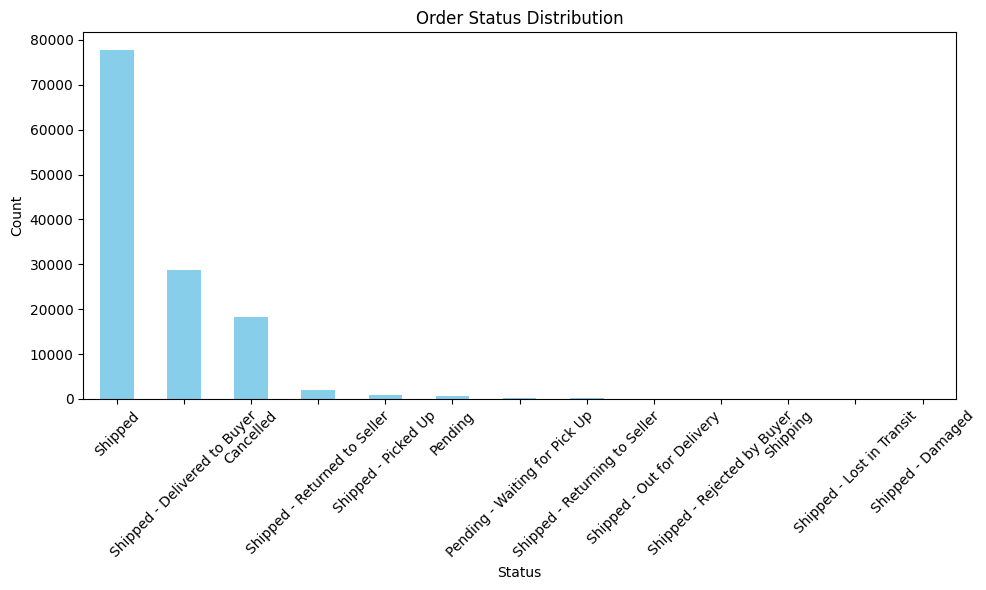

In [8]:
# Visualize Status distribution
plt.figure(figsize=(10, 6))
df['Status'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Order Status Distribution')
plt.xlabel('Status')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

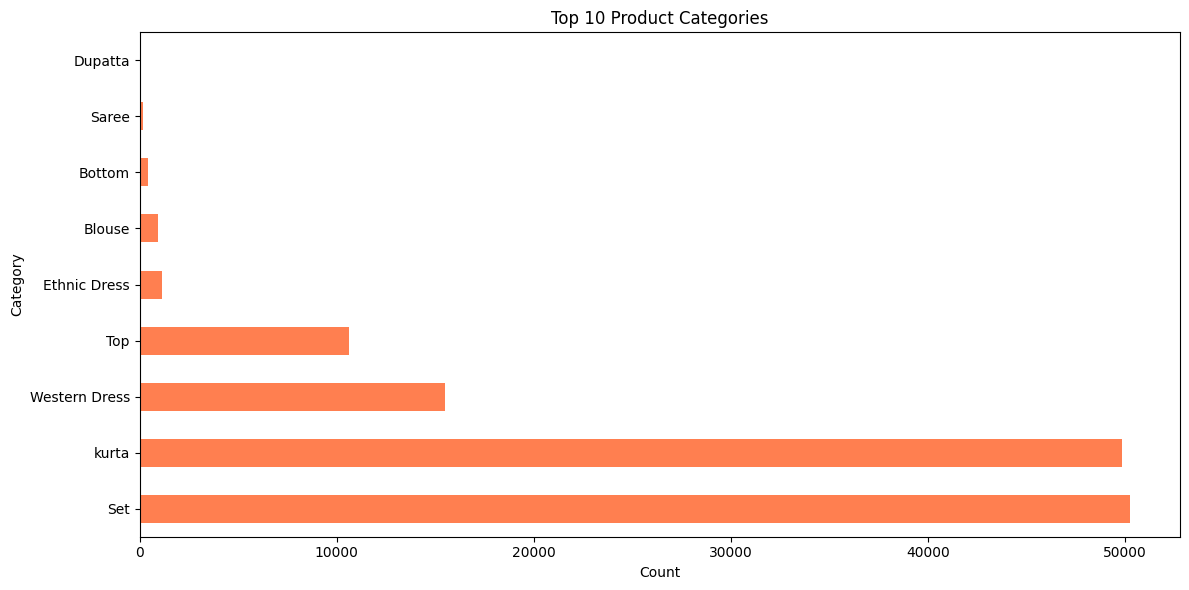

In [9]:
# Visualize top categories
plt.figure(figsize=(12, 6))
df['Category'].value_counts().head(10).plot(kind='barh', color='coral')
plt.title('Top 10 Product Categories')
plt.xlabel('Count')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

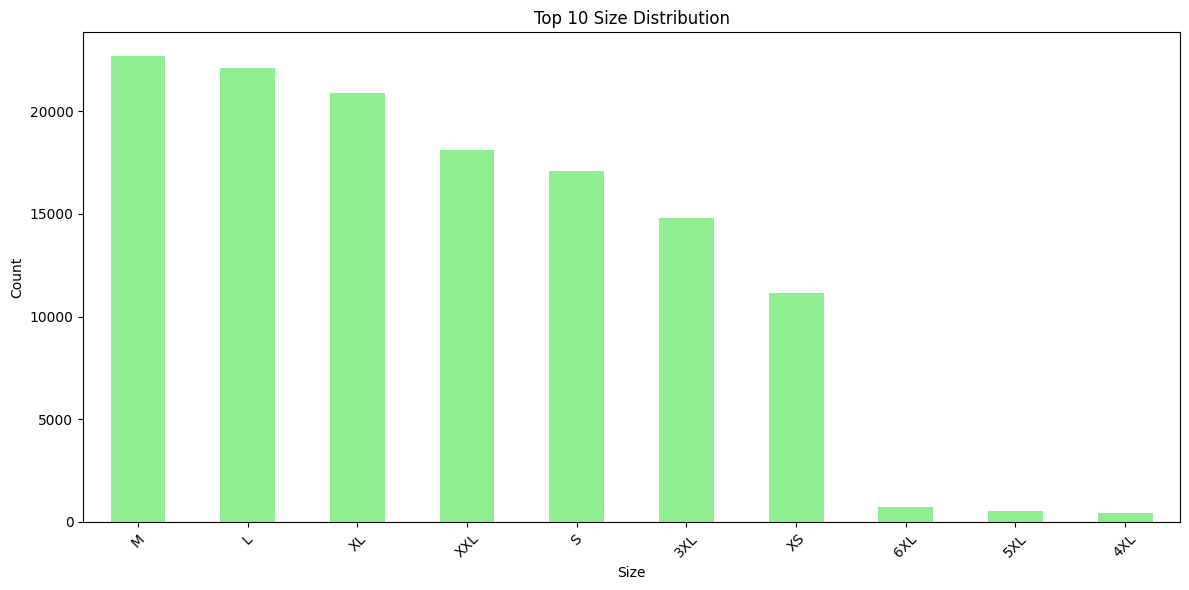

In [10]:
# Visualize size distribution
plt.figure(figsize=(12, 6))
df['Size'].value_counts().head(10).plot(kind='bar', color='lightgreen')
plt.title('Top 10 Size Distribution')
plt.xlabel('Size')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

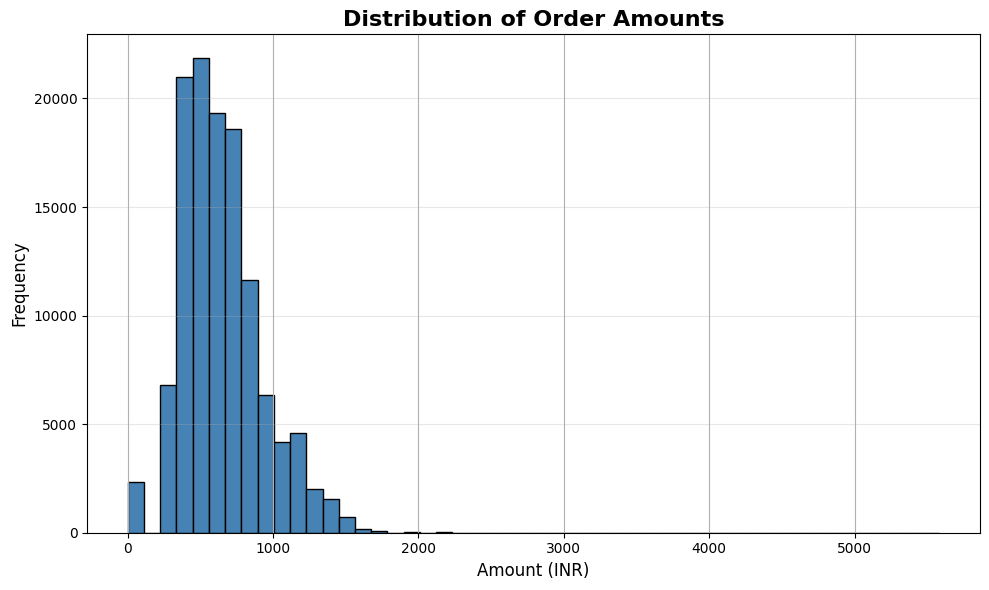

✅ Histogram saved as 'amount_distribution.png'


In [11]:
# 1. Histogram - Amount Distribution
plt.figure(figsize=(10, 6))
df['Amount'].dropna().hist(bins=50, color='steelblue', edgecolor='black')
plt.title('Distribution of Order Amounts', fontsize=16, fontweight='bold')
plt.xlabel('Amount (INR)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('amount_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Histogram saved as 'amount_distribution.png'")

In [12]:
# 2. Line Chart - Try to analyze orders over time
# First, let's check the Date column
print("Checking Date column...")
print(df['Date'].head(10))

Checking Date column...
0    04-30-22
1    04-30-22
2    04-30-22
3    04-30-22
4    04-30-22
5    04-30-22
6    04-30-22
7    04-30-22
8    04-30-22
9    04-30-22
Name: Date, dtype: str


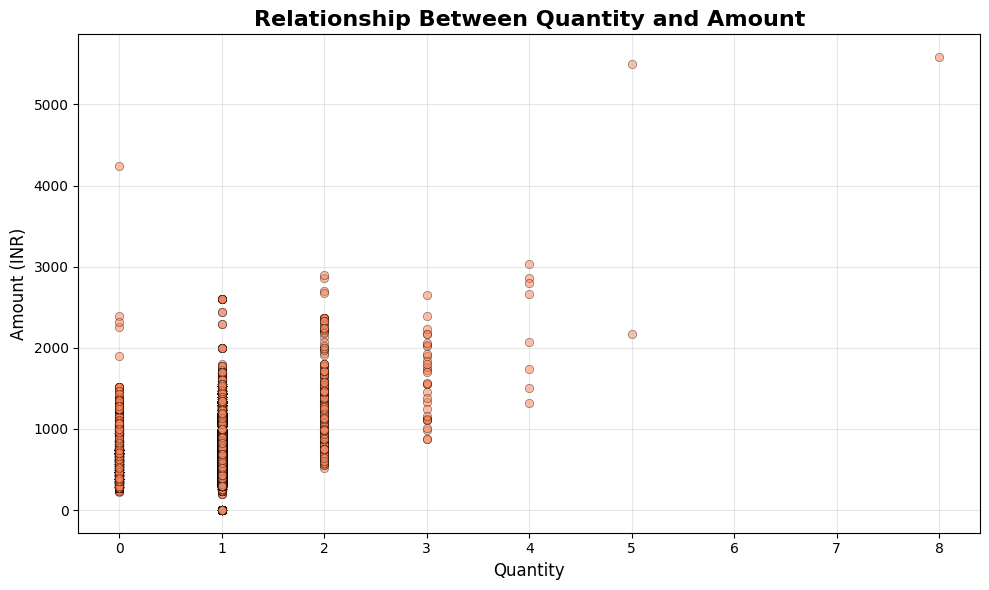

✅ Scatter plot saved as 'qty_vs_amount_scatter.png'


In [13]:
# 3. Scatter Plot - Quantity vs Amount
plt.figure(figsize=(10, 6))
plt.scatter(df['Qty'], df['Amount'], alpha=0.5, color='coral', edgecolors='black', linewidth=0.5)
plt.title('Relationship Between Quantity and Amount', fontsize=16, fontweight='bold')
plt.xlabel('Quantity', fontsize=12)
plt.ylabel('Amount (INR)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('qty_vs_amount_scatter.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Scatter plot saved as 'qty_vs_amount_scatter.png'")

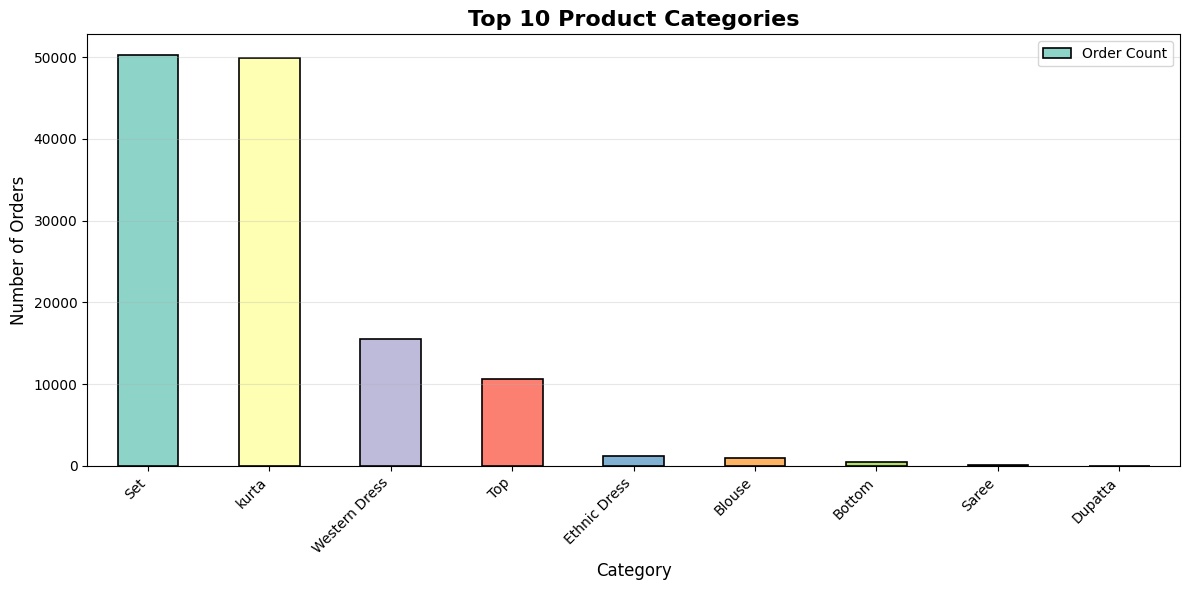

✅ Bar plot saved as 'top_categories_bar.png'


In [14]:
# 4. Enhanced Bar Plot - Top 10 Categories with Custom Styling
plt.figure(figsize=(12, 6))
top_categories = df['Category'].value_counts().head(10)
colors = plt.cm.Set3(range(len(top_categories)))
top_categories.plot(kind='bar', color=colors, edgecolor='black', linewidth=1.2)
plt.title('Top 10 Product Categories', fontsize=16, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(['Order Count'], loc='upper right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('top_categories_bar.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Bar plot saved as 'top_categories_bar.png'")

<Figure size 1200x600 with 0 Axes>

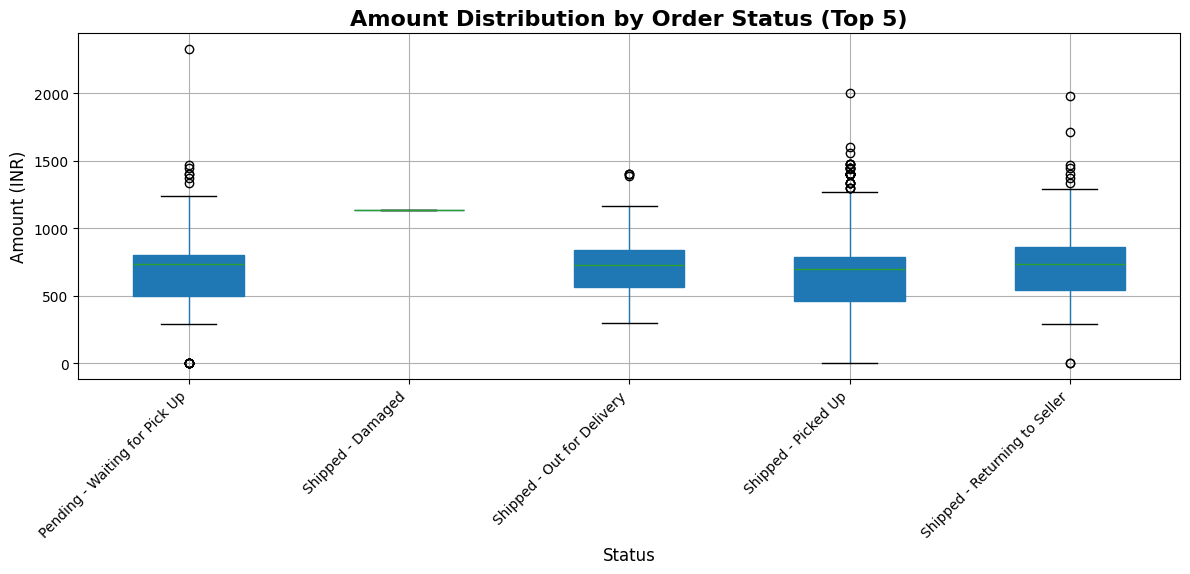

✅ Box plot saved as 'amount_by_status_boxplot.png'


In [15]:
# 5. Box Plot - Amount Distribution by Status
plt.figure(figsize=(12, 6))
status_order = df.groupby('Status')['Amount'].median().sort_values(ascending=False).index[:5]
df_top_status = df[df['Status'].isin(status_order)]
df_top_status.boxplot(column='Amount', by='Status', figsize=(12, 6), patch_artist=True)
plt.title('Amount Distribution by Order Status (Top 5)', fontsize=16, fontweight='bold')
plt.suptitle('')  # Remove auto title
plt.xlabel('Status', fontsize=12)
plt.ylabel('Amount (INR)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('amount_by_status_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Box plot saved as 'amount_by_status_boxplot.png'")